In [ ]:
simport warnings

# Suppress specific UserWarning from librosa related to PySoundFile/audioread
warnings.filterwarnings("ignore", message="PySoundFile failed. Trying audioread instead.")
warnings.filterwarnings("ignore", message="librosa.core.audio.__audioread_load\n\tDeprecated as of librosa version 0.10.0.\n\tIt will be removed in librosa version 1.0.")


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import librosa
import librosa.display
import numpy as np
from pydub import AudioSegment
from pydub.playback import play
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import os

new_metadata_csv_path = '/content/drive/MyDrive/asrdataset/metadata.csv'

try:
    metadata_df_new = pd.read_csv(new_metadata_csv_path, encoding='utf-8')
    print(f"Successfully loaded metadata from {new_metadata_csv_path}")
except UnicodeDecodeError:
    print(f"UnicodeDecodeError: Trying with 'latin1' encoding for {new_metadata_csv_path}")
    metadata_df_new = pd.read_csv(new_metadata_csv_path, encoding='latin1')

metadata_df_new.columns = metadata_df_new.columns.str.strip().str.replace('\t', '', regex=True)

audio_parent_base_path = '/content/drive/MyDrive/asrdataset/audio' # Corrected to lowercase 'audio'

if 'speaker_name' in metadata_df_new.columns:
    # This part is kept for completeness, but not used for path construction if audio files are flat.
    metadata_df_new['speaker_dir_name'] = metadata_df_new['speaker_id'].astype(str) + '_' + metadata_df_new['speaker_name'].str.replace(' ', '').astype(str)
else:
    print("Warning: 'speaker_name' column not found in metadata. Proceeding with direct audio file paths.")
    # The speaker_id is part of the filename, so we don't need a speaker subdirectory for path construction.
    metadata_df_new['speaker_dir_name'] = metadata_df_new['speaker_id'].astype(str) # Still create if other parts of the notebook rely on it.

# Now, create the 'dataset_root' column which is the full path to the audio directory where all WAVs reside.
# If the audio files are directly in 'audio_parent_base_path', then dataset_root is simply this path.
metadata_df_new['dataset_root'] = audio_parent_base_path

# Display some info about the newly prepared metadata_df_new
print("\nNew metadata_df_new info (first 5 rows):")
display(metadata_df_new.head())

Successfully loaded metadata from /content/drive/MyDrive/asrdataset/metadata.csv

New metadata_df_new info (first 5 rows):


,file_name,speaker_id,event_type,speech_text,speech_mode,emotion,expression_style,noise_condition,noise_type,noise_level,recording_environment,device_type,distance,start_time,end_time,duration,quality_label,note,speaker_dir_name,dataset_root
0,22014487_help_call_clean_01.wav,22014487,help_call,"""có ai không? C?u tôi v?i""",scripted,fear,normal,clean,none,none,room,smartphone,near,0.5,3.5,4,good,NaN,22014487,/content/drive/MyDrive/asrdataset/audio
1,22014487_help_call_indoor_noise_02.wav,22014487,help_call,"""làm õn c?u tôi v?i""",scripted,fear,urgent,indoor noise,fan,low,room,smartphone,medium,0.5,3.5,4,good,NaN,22014487,/content/drive/MyDrive/asrdataset/audio
2,22014487_help_call_outdoor_noise_03.wav,22014487,help_call,"""làm õn c?u tôi v?i""",scripted,panic,normal,outdoor_noise,traffic,medium,room,smartphone,medium,0.5,3.5,4,good,NaN,22014487,/content/drive/MyDrive/asrdataset/audio
3,22014487_help_call_crowd_noise_04.wav,22014487,help_call,"""làm õn h?y giúp tôi v?i""",scripted,fear,trembling,crowd_noise,NaN,high,room,smartphone,near,0.5,3.5,4,good,NaN,22014487,/content/drive/MyDrive/asrdataset/audio
4,22014487_help_call_clean_05.wav,22014487,help_call,"""có ai không, làm õn c?u tôi v?i""",scripted,fear,urgent,clean,none,low,room,smartphone,near,0.5,3.5,4,good,NaN,22014487,/content/drive/MyDrive/asrdataset/audio


Processed 195 audio files.

First processed audio item details:
  Original Path: /content/drive/MyDrive/asrdataset/audio/22014487_help_call_clean_01.wav
  Label: help_call
  Audio Waveform Shape: (39936,)
  Sample Rate: 16000


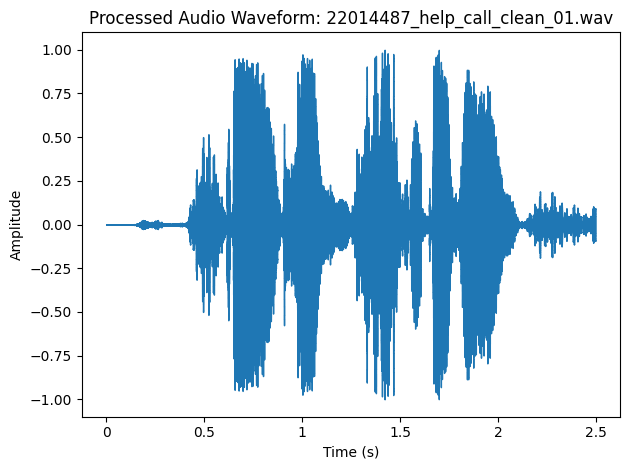

In [ ]:
def preprocess_audio(file_path, target_sr=16000):
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None) # Load with original sampling rate
    except Exception as e:
        print(f"Error loading audio file {file_path}: {e}")
        return None, None # Return None for waveform and sample rate if loading fails

    # 1. Resampling
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    # 2. Advanced Noise Reduction (Spectral Gating)
    if y.size > 0:
        n_fft = 2048
        hop_length = n_fft // 4

        # Short-time Fourier Transform (STFT)
        S_full, phase = librosa.magphase(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))

        # Estimate noise profile from the first few frames (e.g., 0.5 seconds)
        # Assuming the first 0.5 seconds contain mostly noise
        noise_frames_count = min(int(0.5 * sr / hop_length), S_full.shape[1])
        if noise_frames_count > 0:
            noise_profile = np.mean(S_full[:, :noise_frames_count], axis=1, keepdims=True)

            # Apply a spectral gate: only frequencies significantly above the noise profile pass
            # We can use a simple threshold or a more sophisticated gain function
            alpha = 2.0 # Factor to multiply noise profile for the threshold
            threshold = noise_profile * alpha

            # Create a mask: elements above threshold are 1, otherwise 0
            mask = (S_full > threshold).astype(float)

            # Apply mask to the full spectrogram (element-wise multiplication)
            S_filtered = S_full * mask

            # Invert the STFT to get the denoised audio
            y = librosa.istft(S_filtered * phase, hop_length=hop_length)
        else:
            print(f"Warning: Not enough frames for noise reduction in {file_path}. Skipping noise reduction.")

    # 3. Normalization
    y = librosa.util.normalize(y)

    return y, sr

processed_audio_data = []

# Ensure dataset_root paths are correctly cased (lowercase 'audio')
# This is a defensive measure if metadata_df_new wasn't refreshed or contained incorrect paths.
metadata_df_new['dataset_root'] = metadata_df_new['dataset_root'].str.replace(
    '/content/drive/MyDrive/asrdataset/Audio',  # Look for capitalized 'Audio'
    '/content/drive/MyDrive/asrdataset/audio',  # Replace with lowercase 'audio'
    regex=False # Use literal string replacement
)

# Assuming metadata_df_new now has 'file_name', 'event_type', and 'dataset_root' columns
for index, row in metadata_df_new.iterrows():
    # Directly access columns which are guaranteed to exist and be cleaned
    file_name = str(row['file_name']).strip()
    event_type = str(row['event_type']).strip()

    # The 'dataset_root' from metadata_df_new now directly provides the base path for each speaker's audio
    speaker_audio_base_path = str(row['dataset_root']).strip()

    # Check for invalid file_name (e.g., empty string or 'nan' after stripping)
    if not file_name or file_name.lower() == 'nan':
        print(f"Warning: Skipping row {index} due to invalid or missing 'file_name' after cleaning: '{file_name}'.")
        continue

    # Construct the full path to the audio file using the dataset_root from the DataFrame
    full_audio_path = os.path.join(speaker_audio_base_path, file_name)

    if os.path.exists(full_audio_path):
        audio_waveform, sample_rate = preprocess_audio(full_audio_path)
        if audio_waveform is not None:
            processed_audio_data.append({
                'original_path': full_audio_path,
                'label': event_type,
                'audio_waveform': audio_waveform,
                'sample_rate': sample_rate
            })
    else:
        print(f"Warning: Audio file not found at {full_audio_path}")

print(f"Processed {len(processed_audio_data)} audio files.")
if processed_audio_data:
    # Display details of the first processed audio file
    first_processed_item = processed_audio_data[0]
    print("\nFirst processed audio item details:")
    print(f"  Original Path: {first_processed_item['original_path']}")
    print(f"  Label: {first_processed_item['label']}")
    print(f"  Audio Waveform Shape: {first_processed_item['audio_waveform'].shape}")
    print(f"  Sample Rate: {first_processed_item['sample_rate']}")

    # Plot the first processed audio waveform
    import matplotlib.pyplot as plt
    librosa.display.waveshow(first_processed_item['audio_waveform'], sr=first_processed_item['sample_rate'])
    plt.title(f"Processed Audio Waveform: {os.path.basename(first_processed_item['original_path'])}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()
else:
    print("No audio files were processed.")

In [ ]:
framed_audio_data = []

# Define frame length (25 ms) and hop length (10 ms overlap, so hop_length = 25 - 10 = 15 ms)
# Convert milliseconds to samples
def frame_audio(audio_waveform, sample_rate, frame_ms=25, overlap_ms=10):
    frame_length = int(sample_rate * (frame_ms / 1000))
    hop_length = int(sample_rate * ((frame_ms - overlap_ms) / 1000))

    # Ensure frame_length and hop_length are at least 1
    frame_length = max(1, frame_length)
    hop_length = max(1, hop_length)

    frames = librosa.util.frame(audio_waveform, frame_length=frame_length, hop_length=hop_length, axis=0)
    return frames, frame_length, hop_length

for item in processed_audio_data:
    audio_waveform = item['audio_waveform']
    sample_rate = item['sample_rate']
    original_path = item['original_path']
    label = item['label']

    frames, frame_length, hop_length = frame_audio(audio_waveform, sample_rate)

    framed_audio_data.append({
        'original_path': original_path,
        'label': label,
        'frames': frames,
        'sample_rate': sample_rate,
        'frame_length': frame_length,
        'hop_length': hop_length
    })

print(f"Framed {len(framed_audio_data)} audio files.")
if framed_audio_data:
    first_framed_item = framed_audio_data[0]
    print("\nFirst framed audio item details:")
    print(f"  Original Path: {first_framed_item['original_path']}")
    print(f"  Label: {first_framed_item['label']}")
    print(f"  Frames Shape: {first_framed_item['frames'].shape}") # Should be (num_frames, frame_length)
    print(f"  Sample Rate: {first_framed_item['sample_rate']}")
    print(f"  Frame Length (samples): {first_framed_item['frame_length']}")
    print(f"  Hop Length (samples): {first_framed_item['hop_length']}")
else:
    print("No audio files were framed.")

Framed 195 audio files.

First framed audio item details:
  Original Path: /content/drive/MyDrive/asrdataset/audio/22014487_help_call_clean_01.wav
  Label: help_call
  Frames Shape: (165, 400)
  Sample Rate: 16000
  Frame Length (samples): 400
  Hop Length (samples): 240


Extracted features for 195 audio files.

First feature item details:
  Original Path: /content/drive/MyDrive/asrdataset/audio/22014487_help_call_clean_01.wav
  Label: help_call
  MFCCs Shape: (13, 79)
  MFCCs Delta Shape: (13, 79)
  MFCCs Delta2 Shape: (13, 79)
  Mel Spectrogram (dB) Shape: (128, 79)
  Chroma Shape: (12, 79)


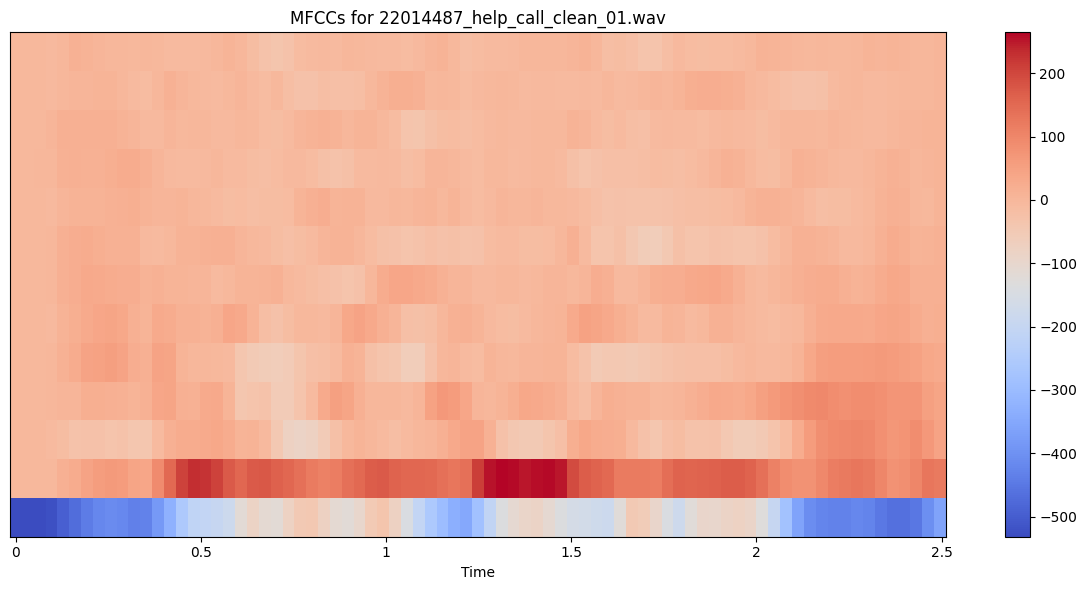

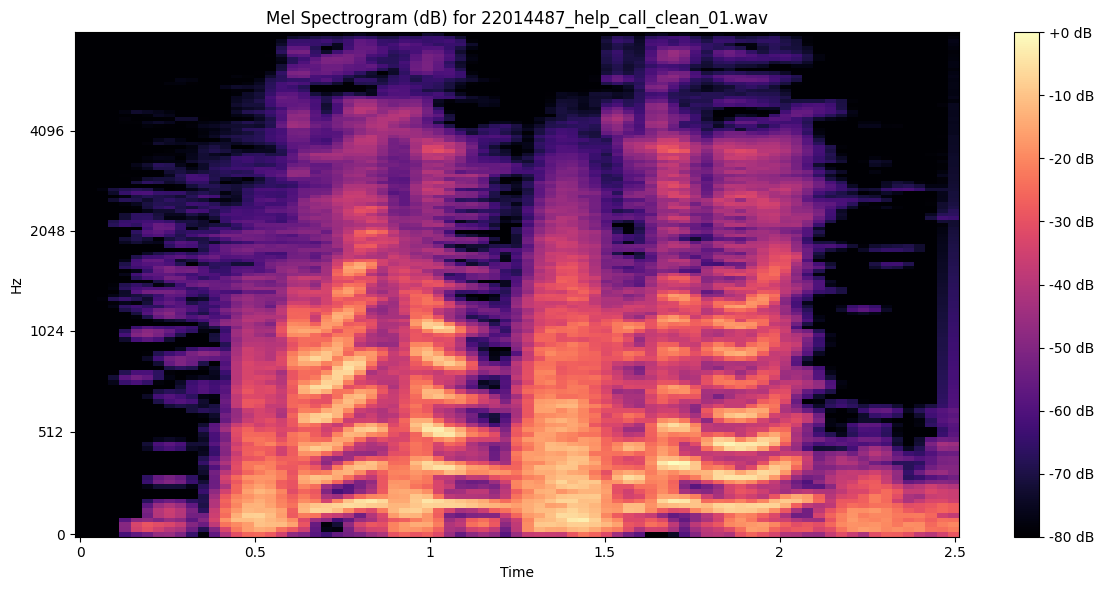

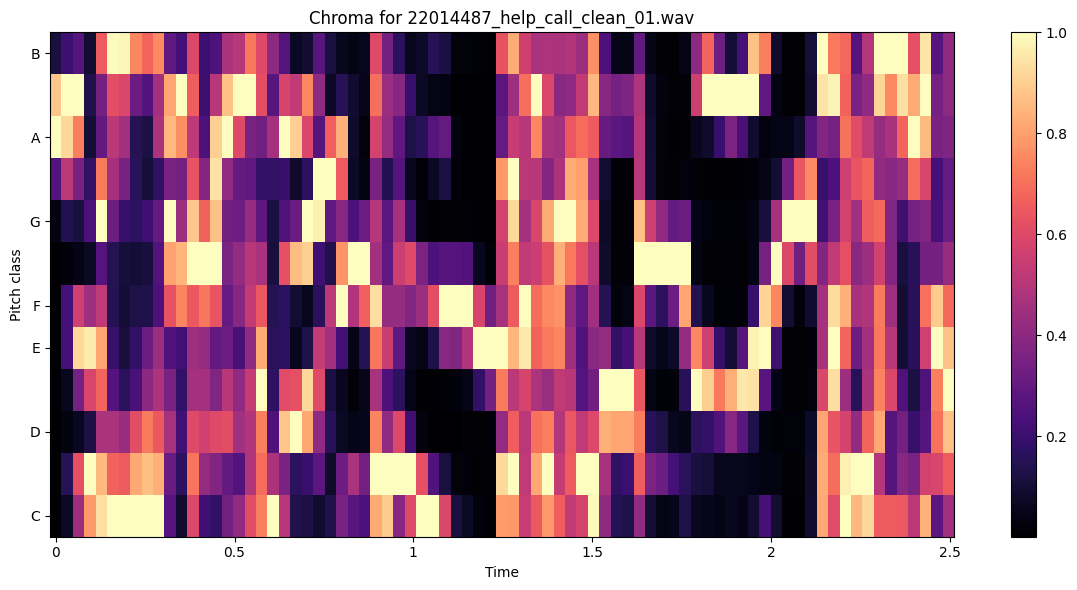

In [ ]:
feature_data = []

def extract_features(audio_waveform, sample_rate, n_mfcc=13):
    # MFCCs
    mfccs = librosa.feature.mfcc(y=audio_waveform, sr=sample_rate, n_mfcc=n_mfcc)
    mfccs_delta = librosa.feature.delta(mfccs)
    mfccs_delta2 = librosa.feature.delta(mfccs, order=2)

    # Mel Spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_waveform, sr=sample_rate)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Chroma features
    chroma = librosa.feature.chroma_stft(y=audio_waveform, sr=sample_rate)

    return mfccs, mfccs_delta, mfccs_delta2, mel_spectrogram_db, chroma


for item in framed_audio_data:
    original_path = item['original_path']
    processed_item_original = next(p for p in processed_audio_data if p['original_path'] == original_path)

    audio_waveform = processed_item_original['audio_waveform']
    sample_rate = processed_item_original['sample_rate']
    label = item['label']

    mfccs, mfccs_delta, mfccs_delta2, mel_spectrogram_db, chroma = extract_features(audio_waveform, sample_rate)

    feature_data.append({
        'original_path': original_path,
        'label': label,
        'mfccs': mfccs,
        'mfccs_delta': mfccs_delta,
        'mfccs_delta2': mfccs_delta2,
        'mel_spectrogram_db': mel_spectrogram_db,
        'chroma': chroma
    })

print(f"Extracted features for {len(feature_data)} audio files.")

if feature_data:
    first_feature_item = feature_data[0]
    print("\nFirst feature item details:")
    print(f"  Original Path: {first_feature_item['original_path']}")
    print(f"  Label: {first_feature_item['label']}")
    print(f"  MFCCs Shape: {first_feature_item['mfccs'].shape}")
    print(f"  MFCCs Delta Shape: {first_feature_item['mfccs_delta'].shape}")
    print(f"  MFCCs Delta2 Shape: {first_feature_item['mfccs_delta2'].shape}")
    print(f"  Mel Spectrogram (dB) Shape: {first_feature_item['mel_spectrogram_db'].shape}")
    print(f"  Chroma Shape: {first_feature_item['chroma'].shape}")

    # Plot MFCCs of the first audio file
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(first_feature_item['mfccs'], sr=sample_rate, x_axis='time')
    plt.colorbar()
    plt.title(f"MFCCs for {os.path.basename(first_feature_item['original_path'])}")
    plt.tight_layout()
    plt.show()

    # Plot Mel Spectrogram of the first audio file
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(first_feature_item['mel_spectrogram_db'], sr=sample_rate, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel Spectrogram (dB) for {os.path.basename(first_feature_item['original_path'])}")
    plt.tight_layout()
    plt.show()

    # Plot Chroma of the first audio file
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(first_feature_item['chroma'], sr=sample_rate, x_axis='time', y_axis='chroma')
    plt.colorbar()
    plt.title(f"Chroma for {os.path.basename(first_feature_item['original_path'])}")
    plt.tight_layout()
    plt.show()
else:
    print("No features were extracted.")

In [ ]:
aggregated_feature_data = []

for item in feature_data:
    mfccs = item['mfccs']
    mfccs_delta = item['mfccs_delta']
    mfccs_delta2 = item['mfccs_delta2']
    mel_spectrogram_db = item['mel_spectrogram_db']
    chroma = item['chroma']

    # Aggregate MFCCs: mean and standard deviation
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std = np.std(mfccs, axis=1)

    mfccs_delta_mean = np.mean(mfccs_delta, axis=1)
    mfccs_delta_std = np.std(mfccs_delta, axis=1)

    mfccs_delta2_mean = np.mean(mfccs_delta2, axis=1)
    mfccs_delta2_std = np.std(mfccs_delta2, axis=1)

    # Aggregate Mel Spectrogram: mean and standard deviation
    mel_spectrogram_mean = np.mean(mel_spectrogram_db, axis=1)
    mel_spectrogram_std = np.std(mel_spectrogram_db, axis=1)

    # Aggregate Chroma: mean and standard deviation
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)

    # Combine all aggregated features into a single flattened vector
    # Concatenate mean and std for each feature type
    feature_vector = np.concatenate([
        mfccs_mean, mfccs_std,
        mfccs_delta_mean, mfccs_delta_std,
        mfccs_delta2_mean, mfccs_delta2_std,
        mel_spectrogram_mean, mel_spectrogram_std,
        chroma_mean, chroma_std
    ])

    aggregated_feature_data.append({
        'original_path': item['original_path'],
        'label': item['label'],
        'feature_vector': feature_vector
    })

print(f"Aggregated features for {len(aggregated_feature_data)} audio files.")

if aggregated_feature_data:
    first_aggregated_item = aggregated_feature_data[0]
    print("\nFirst aggregated feature item details:")
    print(f"  Original Path: {first_aggregated_item['original_path']}")
    print(f"  Label: {first_aggregated_item['label']}")
    print(f"  Aggregated Feature Vector Shape: {first_aggregated_item['feature_vector'].shape}")
    print(f"  First 10 values of Feature Vector: {first_aggregated_item['feature_vector'][:10]}")
else:
    print("No features were aggregated.")

Aggregated features for 195 audio files.

First aggregated feature item details:
  Original Path: /content/drive/MyDrive/asrdataset/audio/22014487_help_call_clean_01.wav
  Label: help_call
  Aggregated Feature Vector Shape: (358,)
  First 10 values of Feature Vector: [-2.44703706e+02  1.36468486e+02  2.31887954e+00  2.50683699e+01
  1.87808518e-01  1.24765498e+01  1.11619867e+01 -6.81247379e+00
 -1.42404546e+00 -2.93409850e+00]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
from sklearn.preprocessing import StandardScaler

# Prepare data for ML model
X = np.array([item['feature_vector'] for item in aggregated_feature_data])
y = np.array([item['label'] for item in aggregated_feature_data])

print(f"Total samples: {len(X)}")
print(f"Feature vector dimension: {X.shape[1]}")
print(f"Unique labels: {np.unique(y)}")

# Identify classes with only one member
label_counts = Counter(y)
single_member_classes = [label for label, count in label_counts.items() if count < 2]

if single_member_classes:
    print(f"\nWarning: Found classes with fewer than 2 samples (will be excluded from stratified split): {single_member_classes}")
    # Filter out samples belonging to single-member classes
    valid_indices = [i for i, label in enumerate(y) if label not in single_member_classes]
    X_filtered = X[valid_indices]
    y_filtered = y[valid_indices]
    print(f"Filtered down to {len(X_filtered)} samples for splitting.")
else:
    X_filtered = X
    y_filtered = y

if len(np.unique(y_filtered)) < 2 or len(y_filtered) < 2:
    print("\nError: Not enough samples or unique classes remaining after filtering for stratified split.")
else:
    # Split data into training and testing sets
    # Using a common split ratio, e.g., 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)

    # Scale features for KNN (important for distance-based algorithms)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\nTraining set size: {len(X_train_scaled)} samples")
    print(f"Testing set size: {len(X_test_scaled)} samples")

    # Initialize and train the KNN model
    # You can experiment with different values for n_neighbors
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = knn.predict(X_test_scaled)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)

    print(f"\nKNN Model Accuracy (with scaling): {accuracy:.4f}")
    print("\nClassification Report (KNN with scaling):\n", report)


Total samples: 195
Feature vector dimension: 358
Unique labels: ['accident_report' 'calm_down' 'help_call' 'non_emergency'
 'panic_reaction' 'threat' 'urgent_call']

Training set size: 156 samples
Testing set size: 39 samples

KNN Model Accuracy (with scaling): 0.2308

Classification Report (KNN with scaling):
                  precision    recall  f1-score   support

accident_report       0.29      0.40      0.33         5
      calm_down       0.00      0.00      0.00         5
      help_call       0.38      0.60      0.46         5
  non_emergency       0.25      0.33      0.29         9
 panic_reaction       0.25      0.20      0.22         5
         threat       0.00      0.00      0.00         5
    urgent_call       0.00      0.00      0.00         5

       accuracy                           0.23        39
      macro avg       0.17      0.22      0.19        39
   weighted avg       0.17      0.23      0.20        39



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, zero_division=0)

print(f"\nSVM Model Accuracy: {accuracy_svm:.4f}")
print("\nClassification Report (SVM):\n", report_svm)


SVM Model Accuracy: 0.2308

Classification Report (SVM):
                  precision    recall  f1-score   support

accident_report       0.22      0.40      0.29         5
      calm_down       0.00      0.00      0.00         5
      help_call       0.50      0.40      0.44         5
  non_emergency       0.27      0.44      0.33         9
 panic_reaction       0.00      0.00      0.00         5
         threat       0.33      0.20      0.25         5
    urgent_call       0.00      0.00      0.00         5

       accuracy                           0.23        39
      macro avg       0.19      0.21      0.19        39
   weighted avg       0.20      0.23      0.20        39



In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
# Increase max_iter for convergence with complex datasets
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and L1/L2 regularization
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, zero_division=0)

print(f"\nLogistic Regression Model Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report (Logistic Regression):\n", report_lr)


Logistic Regression Model Accuracy: 0.1795

Classification Report (Logistic Regression):
                  precision    recall  f1-score   support

accident_report       0.00      0.00      0.00         5
      calm_down       0.00      0.00      0.00         5
      help_call       0.43      0.60      0.50         5
  non_emergency       0.17      0.22      0.19         9
 panic_reaction       0.00      0.00      0.00         5
         threat       0.00      0.00      0.00         5
    urgent_call       0.50      0.40      0.44         5

       accuracy                           0.18        39
      macro avg       0.16      0.17      0.16        39
   weighted avg       0.16      0.18      0.17        39



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, zero_division=0)

print(f"\nRandom Forest Model Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report (Random Forest):\n", report_rf)


Random Forest Model Accuracy: 0.1538

Classification Report (Random Forest):
                  precision    recall  f1-score   support

accident_report       0.00      0.00      0.00         5
      calm_down       0.00      0.00      0.00         5
      help_call       0.50      0.20      0.29         5
  non_emergency       0.17      0.44      0.25         9
 panic_reaction       0.11      0.20      0.14         5
         threat       0.00      0.00      0.00         5
    urgent_call       0.00      0.00      0.00         5

       accuracy                           0.15        39
      macro avg       0.11      0.12      0.10        39
   weighted avg       0.12      0.15      0.11        39



In [ ]:
pip install transformers accelerate

In [ ]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torch

# Load pre-trained Wav2Vec2 model and processor
# Using a base model for demonstration, you might want to try a larger or fine-tuned one later
processor_wav2vec = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model_wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

def extract_wav2vec_embeddings(audio_waveform, sample_rate):
    # Ensure audio is at 16kHz, which Wav2Vec2 expects
    # The preprocess_audio function already resamples to 16kHz, but we double-check here.
    # Wav2Vec2Processor automatically handles resampling if needed, but it's good practice.
    inputs = processor_wav2vec(audio_waveform, sampling_rate=sample_rate, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model_wav2vec(**inputs)

    # Extract the last hidden states (embeddings)
    # The output is (batch_size, sequence_length, hidden_size)
    # We take the mean across the sequence length to get a fixed-size vector for the entire audio clip
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embeddings

print("Wav2Vec2 model and processor loaded successfully.")

# Example of extracting embeddings for the first processed audio file
if processed_audio_data:
    first_audio = processed_audio_data[0]
    wav2vec_emb = extract_wav2vec_embeddings(first_audio['audio_waveform'], first_audio['sample_rate'])
    print(f"\nExtracted Wav2Vec2 embeddings shape for first audio: {wav2vec_emb.shape}")
else:
    print("No processed audio data available to demonstrate Wav2Vec2 embedding extraction.")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2 model and processor loaded successfully.

Extracted Wav2Vec2 embeddings shape for first audio: (768,)


In [ ]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch # Added this import

# Load pre-trained Whisper model and processor
# Using 'openai/whisper-base' for demonstration. For PhoWhisper, replace with 'VinAI/PhoWhisper-large'
processor_whisper = AutoProcessor.from_pretrained("openai/whisper-base")
model_whisper = AutoModelForSpeechSeq2Seq.from_pretrained("openai/whisper-base")

def extract_whisper_embeddings(audio_waveform, sample_rate):
    # Whisper models expect 16kHz audio
    inputs = processor_whisper(audio_waveform, sampling_rate=sample_rate, return_tensors="pt").input_features

    with torch.no_grad():
        # Get the encoder hidden states. These are the audio embeddings.
        outputs = model_whisper.get_encoder().forward(inputs)

    # The output is (batch_size, sequence_length, hidden_size)
    # We take the mean across the sequence length to get a fixed-size vector for the entire audio clip
    # Corrected: Access last_hidden_state from the BaseModelOutput object
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embeddings

print("Whisper model and processor loaded successfully.")

# Example of extracting embeddings for the first processed audio file
if processed_audio_data:
    first_audio = processed_audio_data[0]
    whisper_emb = extract_whisper_embeddings(first_audio['audio_waveform'], first_audio['sample_rate'])
    print(f"\nExtracted Whisper embeddings shape for first audio: {whisper_emb.shape}")
else:
    print("No processed audio data available to demonstrate Whisper embedding extraction.")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Whisper model and processor loaded successfully.

Extracted Whisper embeddings shape for first audio: (512,)


In [ ]:
# Re-defining feature_data to include new embeddings
# It's better to create a new list or extend existing ones to avoid confusion
feature_data_with_dl = []

for item in processed_audio_data:
    original_path = item['original_path']
    audio_waveform = item['audio_waveform']
    sample_rate = item['sample_rate']
    label = item['label']

    # Extract traditional features
    mfccs, mfccs_delta, mfccs_delta2, mel_spectrogram_db, chroma = extract_features(audio_waveform, sample_rate)

    # Extract Wav2Vec2 embeddings
    wav2vec_embeddings = extract_wav2vec_embeddings(audio_waveform, sample_rate)

    # Extract Whisper embeddings
    whisper_embeddings = extract_whisper_embeddings(audio_waveform, sample_rate)

    feature_data_with_dl.append({
        'original_path': original_path,
        'label': label,
        'mfccs': mfccs,
        'mfccs_delta': mfccs_delta,
        'mfccs_delta2': mfccs_delta2,
        'mel_spectrogram_db': mel_spectrogram_db,
        'chroma': chroma,
        'wav2vec_embeddings': wav2vec_embeddings, # Add Wav2Vec2 embeddings
        'whisper_embeddings': whisper_embeddings  # Add Whisper embeddings
    })

print(f"Extracted features (including DL embeddings) for {len(feature_data_with_dl)} audio files.")

# Now, you would proceed to aggregate these features as before, including the new embeddings.
# For example, you can concatenate the DL embeddings directly with the aggregated traditional features.

# Example of aggregation (re-using the previous aggregation logic and adding DL embeddings)
aggregated_feature_data_with_dl = []

for item_dl in feature_data_with_dl:
    mfccs = item_dl['mfccs']
    mfccs_delta = item_dl['mfccs_delta']
    mfccs_delta2 = item_dl['mfccs_delta2']
    mel_spectrogram_db = item_dl['mel_spectrogram_db']
    chroma = item_dl['chroma']
    wav2vec_embeddings = item_dl['wav2vec_embeddings']
    whisper_embeddings = item_dl['whisper_embeddings']

    # Aggregate traditional features: mean and standard deviation
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std = np.std(mfccs, axis=1)
    mfccs_delta_mean = np.mean(mfccs_delta, axis=1)
    mfccs_delta_std = np.std(mfccs_delta, axis=1)
    mfccs_delta2_mean = np.mean(mfccs_delta2, axis=1)
    mfccs_delta2_std = np.std(mfccs_delta2, axis=1)
    mel_spectrogram_mean = np.mean(mel_spectrogram_db, axis=1)
    mel_spectrogram_std = np.std(mel_spectrogram_db, axis=1)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)

    # Combine all aggregated features and deep learning embeddings into a single flattened vector
    feature_vector_dl = np.concatenate([
        mfccs_mean, mfccs_std,
        mfccs_delta_mean, mfccs_delta_std,
        mfccs_delta2_mean, mfccs_delta2_std,
        mel_spectrogram_mean, mel_spectrogram_std,
        chroma_mean, chroma_std,
        wav2vec_embeddings, # Add Wav2Vec2 embeddings
        whisper_embeddings  # Add Whisper embeddings
    ])

    aggregated_feature_data_with_dl.append({
        'original_path': item_dl['original_path'],
        'label': item_dl['label'],
        'feature_vector': feature_vector_dl
    })

print(f"Aggregated features (including DL embeddings) for {len(aggregated_feature_data_with_dl)} audio files.")

if aggregated_feature_data_with_dl:
    first_aggregated_dl_item = aggregated_feature_data_with_dl[0]
    print("\nFirst aggregated feature item with DL embeddings details:")
    print(f"  Original Path: {first_aggregated_dl_item['original_path']}")
    print(f"  Label: {first_aggregated_dl_item['label']}")
    print(f"  Aggregated Feature Vector Shape: {first_aggregated_dl_item['feature_vector'].shape}")
    print(f"  First 10 values of Feature Vector: {first_aggregated_dl_item['feature_vector'][:10]}")

Extracted features (including DL embeddings) for 195 audio files.
Aggregated features (including DL embeddings) for 195 audio files.

First aggregated feature item with DL embeddings details:
  Original Path: /content/drive/MyDrive/asrdataset/audio/22014487_help_call_clean_01.wav
  Label: help_call
  Aggregated Feature Vector Shape: (1638,)
  First 10 values of Feature Vector: [-2.44703706e+02  1.36468486e+02  2.31887954e+00  2.50683699e+01
  1.87808518e-01  1.24765498e+01  1.11619867e+01 -6.81247379e+00
 -1.42404546e+00 -2.93409850e+00]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Prepare data for DL model using features with DL embeddings
X_dl = np.array([item['feature_vector'] for item in aggregated_feature_data_with_dl])
y_dl = np.array([item['label'] for item in aggregated_feature_data_with_dl])

# Encode labels to numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_dl)
y_categorical = to_categorical(y_encoded)

print(f"Total samples for DL: {len(X_dl)}")
print(f"Feature vector dimension for DL: {X_dl.shape[1]}")
print(f"Number of unique classes: {len(label_encoder.classes_)}")
print(f"Original labels: {label_encoder.classes_}")

# Split data into training and testing sets
# Using the same split as before for consistency
# Filter out single-member classes if any
label_counts_dl = Counter(y_dl)
single_member_classes_dl = [label for label, count in label_counts_dl.items() if count < 2]

if single_member_classes_dl:
    print(f"\nWarning: Found classes with fewer than 2 samples (will be excluded from stratified split for DL): {single_member_classes_dl}")
    valid_indices_dl = [i for i, label in enumerate(y_dl) if label not in single_member_classes_dl]
    X_dl_filtered = X_dl[valid_indices_dl]
    y_dl_filtered = y_encoded[valid_indices_dl]
    y_dl_categorical_filtered = y_categorical[valid_indices_dl]
    print(f"Filtered down to {len(X_dl_filtered)} samples for DL splitting.")
else:
    X_dl_filtered = X_dl
    y_dl_filtered = y_encoded
    y_dl_categorical_filtered = y_categorical

if len(np.unique(y_dl_filtered)) < 2 or len(y_dl_filtered) < 2:
    print("\nError: Not enough samples or unique classes remaining after filtering for stratified split for DL.")
else:
    X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
        X_dl_filtered, y_dl_categorical_filtered, test_size=0.2, random_state=42, stratify=y_dl_filtered
    )

    # Scale features for the neural network
    scaler_dl = StandardScaler()
    X_train_dl_scaled = scaler_dl.fit_transform(X_train_dl)
    X_test_dl_scaled = scaler_dl.transform(X_test_dl)

    print(f"\nTraining set size for DL: {len(X_train_dl_scaled)} samples")
    print(f"Testing set size for DL: {len(X_test_dl_scaled)} samples")

Total samples for DL: 195
Feature vector dimension for DL: 1638
Number of unique classes: 7
Original labels: ['accident_report' 'calm_down' 'help_call' 'non_emergency'
 'panic_reaction' 'threat' 'urgent_call']

Training set size for DL: 156 samples
Testing set size for DL: 39 samples


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report

# Define the MLP model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dl_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
history = model.fit(
    X_train_dl_scaled, y_train_dl, # Use scaled features and categorical labels
    epochs=15, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1
)

# Evaluate the model on the test set
loss, accuracy_dl = model.evaluate(X_test_dl_scaled, y_test_dl, verbose=0)

print(f"\nDeep Learning (MLP) Model Accuracy: {accuracy_dl:.4f}")

# Make predictions for classification report
y_pred_proba_dl = model.predict(X_test_dl_scaled)
y_pred_dl = np.argmax(y_pred_proba_dl, axis=1)
y_test_labels = np.argmax(y_test_dl, axis=1)

# Convert numerical predictions and true labels back to original class names for report
y_pred_class_names = label_encoder.inverse_transform(y_pred_dl)
y_test_class_names = label_encoder.inverse_transform(y_test_labels)

report_dl = classification_report(y_test_class_names, y_pred_class_names, zero_division=0)
print("\nClassification Report (Deep Learning MLP):\n", report_dl)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │       419,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 453,383 (1.73 MB)

 Trainable params: 453,383 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.1371 - loss: 2.9581 - val_accuracy: 0.2188 - val_loss: 2.2001
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3710 - loss: 1.6875 - val_accuracy: 0.1875 - val_loss: 2.1151
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5081 - loss: 1.4106 - val_accuracy: 0.3125 - val_loss: 1.9791
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6532 - loss: 1.1665 - val_accuracy: 0.2188 - val_loss: 1.9378
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6532 - loss: 0.9469 - val_accuracy: 0.2500 - val_loss: 2.0406
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7984 - loss: 0.5777 - val_accuracy: 0.1875 - val_loss: 2.1148
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8629 - loss: 0.4894 - val_accuracy: 0.1875 - val_loss: 2.2463
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8065 - loss: 0.5721 - val_accuracy: 0.1875 - val_loss: 2.3369

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine max sequence length for temporal features
# We'll consider MFCCs, Mel-spectrogram, and Chroma. We need a common length.
# Let's find the maximum length across all these features for all audio files.
# If a fixed value is desired, it can be set manually.
MAX_SEQUENCE_LENGTH = 0
for item_dl in feature_data_with_dl:
    # Assuming mfccs, mel_spectrogram_db, and chroma have the same time dimension
    if item_dl['mfccs'].shape[1] > MAX_SEQUENCE_LENGTH:
        MAX_SEQUENCE_LENGTH = item_dl['mfccs'].shape[1]

print(f"Maximum sequence length found: {MAX_SEQUENCE_LENGTH}")

# If MAX_SEQUENCE_LENGTH is too small or too large, you might want to adjust it manually.
# For consistency, let's cap it to a reasonable value if it's very large, or set a minimum.
# Here, we'll use the dynamically determined max length.

def prepare_sequential_features(feature_data_item, max_len):
    mfccs = feature_data_item['mfccs']  # Shape (n_mfcc, time_steps)
    mel_spectrogram_db = feature_data_item['mel_spectrogram_db'] # Shape (n_mels, time_steps)
    chroma = feature_data_item['chroma'] # Shape (n_chroma, time_steps)

    # Transpose to (time_steps, features) for padding and consistent concatenation
    mfccs_transposed = mfccs.T
    mel_transposed = mel_spectrogram_db.T
    chroma_transposed = chroma.T

    # Pad/truncate each feature type to max_len
    # pad_sequences expects (num_samples, timesteps, features) or (num_samples, timesteps)
    # We need to apply it to each feature independently, then concatenate or use a custom pad function

    # Since these are 2D arrays (time, features), we can pad them directly
    mfccs_padded = pad_sequences([mfccs_transposed], maxlen=max_len, dtype='float32', padding='post', truncating='post', value=0.0)[0]
    mel_padded = pad_sequences([mel_transposed], maxlen=max_len, dtype='float32', padding='post', truncating='post', value=0.0)[0]
    chroma_padded = pad_sequences([chroma_transposed], maxlen=max_len, dtype='float32', padding='post', truncating='post', value=0.0)[0]

    # Concatenate features along the feature dimension for each timestep
    # Resulting shape: (max_len, n_mfcc + n_mels + n_chroma)
    combined_sequential_feature = np.concatenate([mfccs_padded, mel_padded, chroma_padded], axis=-1)
    return combined_sequential_feature

X_seq_data = []
X_dl_static_data = [] # Combined Wav2Vec2 and Whisper embeddings

for item_dl in feature_data_with_dl:
    sequential_features = prepare_sequential_features(item_dl, MAX_SEQUENCE_LENGTH)
    X_seq_data.append(sequential_features)

    # Combine Wav2Vec2 and Whisper embeddings for static input
    static_embeddings = np.concatenate([
        item_dl['wav2vec_embeddings'],
        item_dl['whisper_embeddings']
    ])
    X_dl_static_data.append(static_embeddings)

X_seq_data = np.array(X_seq_data)
X_dl_static_data = np.array(X_dl_static_data)

# Ensure labels are also aligned and in categorical format (y_dl_categorical_filtered from previous cell)

# Apply the same filtering as done for the labels
# y_dl_filtered and y_dl_categorical_filtered were generated from the filtered data
# We need to ensure X_seq_data and X_dl_static_data also correspond to the filtered labels.
X_seq_data_filtered = X_seq_data[valid_indices_dl]
X_dl_static_data_filtered = X_dl_static_data[valid_indices_dl]

# Explicitly filter y_dl_categorical_filtered and y_dl_filtered with valid_indices_dl
# to ensure consistency with X_seq_data_filtered and X_dl_static_data_filtered
y_dl_categorical_filtered_seq = y_dl_categorical_filtered[valid_indices_dl]
y_dl_filtered_seq = y_dl_filtered[valid_indices_dl]

# Re-split data to ensure consistency with new feature sets
# We need to stratify based on the original labels to maintain class distribution
from sklearn.model_selection import train_test_split

# Use y_dl_filtered_seq (numerical labels before one-hot encoding) for stratification
# This ensures correct stratification for multi-output split (X_seq, X_static)
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train_seq, y_test_seq = train_test_split(
    X_seq_data_filtered, X_dl_static_data_filtered, y_dl_categorical_filtered_seq,
    test_size=0.2, random_state=42, stratify=y_dl_filtered_seq # Use non-categorical for stratify
)

# Scale sequential features (if desired, per feature channel across time)
# For CNNs/RNNs, it's often scaled per feature dimension.
# Let's flatten for StandardScaler temporarily, then reshape back.

# Scaler for sequential data
scaler_seq = StandardScaler()
original_shape_train = X_seq_train.shape
X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train.reshape(-1, original_shape_train[-1])).reshape(original_shape_train)
original_shape_test = X_seq_test.shape
X_seq_test_scaled = scaler_seq.transform(X_seq_test.reshape(-1, original_shape_test[-1])).reshape(original_shape_test)

# Scaler for static DL embeddings
scaler_static = StandardScaler()
X_static_train_scaled = scaler_static.fit_transform(X_static_train)
X_static_test_scaled = scaler_static.transform(X_static_test)

print(f"\nPrepared Sequential Feature Data Shape (Train): {X_seq_train_scaled.shape}")
print(f"Prepared Sequential Feature Data Shape (Test): {X_seq_test_scaled.shape}")
print(f"Prepared Static DL Embeddings Data Shape (Train): {X_static_train_scaled.shape}")
print(f"Prepared Static DL Embeddings Data Shape (Test): {X_static_test_scaled.shape}")
print(f"Labels Shape (Train): {y_train_seq.shape}")
print(f"Labels Shape (Test): {y_test_seq.shape}")

Maximum sequence length found: 148

Prepared Sequential Feature Data Shape (Train): (154, 148, 153)
Prepared Sequential Feature Data Shape (Test): (39, 148, 153)
Prepared Static DL Embeddings Data Shape (Train): (154, 1280)
Prepared Static DL Embeddings Data Shape (Test): (39, 1280)
Labels Shape (Train): (154, 7)
Labels Shape (Test): (39, 7)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, concatenate
from tensorflow.keras.optimizers import Adam

# Define the input layers
sequential_input = Input(shape=(X_seq_train_scaled.shape[1], X_seq_train_scaled.shape[2]), name='sequential_input')
static_input = Input(shape=(X_static_train_scaled.shape[1],), name='static_input')

# Branch for sequential features (CNN part)
x = Conv1D(filters=64, kernel_size=3, activation='relu')(sequential_input)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)
x = Conv1D(filters=128, kernel_size=3, activation='relu')(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
cnn_output = x

# Combine CNN output with static embeddings
merged = concatenate([cnn_output, static_input])

# Output layer
output = Dense(len(label_encoder.classes_), activation='softmax')(merged)

# Create the model
cnn_model = Model(inputs=[sequential_input, static_input], outputs=output)

# Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
cnn_model.summary()

# Train the CNN model
history_cnn = cnn_model.fit(
    {'sequential_input': X_seq_train_scaled, 'static_input': X_static_train_scaled},
    y_train_seq,
    epochs=15, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the CNN model on the test set
loss_cnn, accuracy_cnn = cnn_model.evaluate(
    {'sequential_input': X_seq_test_scaled, 'static_input': X_static_test_scaled},
    y_test_seq,
    verbose=0
)

print(f"\nDeep Learning (CNN) Model Accuracy: {accuracy_cnn:.4f}")

# Make predictions for classification report
y_pred_proba_cnn = cnn_model.predict({'sequential_input': X_seq_test_scaled, 'static_input': X_static_test_scaled})
y_pred_cnn = np.argmax(y_pred_proba_cnn, axis=1)
y_test_labels_cnn = np.argmax(y_test_seq, axis=1)

# Convert numerical predictions and true labels back to original class names for report
y_pred_class_names_cnn = label_encoder.inverse_transform(y_pred_cnn)
y_test_class_names_cnn = label_encoder.inverse_transform(y_test_labels_cnn)

report_cnn = classification_report(y_test_class_names_cnn, y_pred_class_names_cnn, zero_division=0)
print("\nClassification Report (Deep Learning CNN):\n", report_cnn)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequential_input    │ (None, 148, 153)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 146, 64)   │     29,440 │ sequential_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 73, 64)    │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 73, 64)    │          0 │ max_pooling1d_6[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 71, 128)   │     24,704 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 35, 128)   │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 35, 128)   │          0 │ max_pooling1d_7[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4480)      │          0 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │    573,568 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 128)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 1408)      │          0 │ dropout_28[0][0], │
│ (Concatenate)       │                   │            │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 7)         │      9,863 │ concatenate_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 637,575 (2.43 MB)

 Trainable params: 637,575 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.1707 - loss: 2.6516 - val_accuracy: 0.2258 - val_loss: 2.1193
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3252 - loss: 1.8260 - val_accuracy: 0.1935 - val_loss: 2.0587
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4553 - loss: 1.5377 - val_accuracy: 0.2258 - val_loss: 1.9388
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5447 - loss: 1.2448 - val_accuracy: 0.3871 - val_loss: 1.7482
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7154 - loss: 0.9897 - val_accuracy: 0.3548 - val_loss: 1.6936
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7805 - loss: 0.8062 - val_accuracy: 0.3871 - val_loss: 1.6760
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8537 - loss: 0.6583 - val_accuracy: 0.3548 - val_loss: 1.6901
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9268 - loss: 0.5424 - val_accuracy: 0.3226 - val_loss: 1.702

In [ ]:
from tensorflow.keras.layers import LSTM, GRU

# Define the input layers (same as CNN)
sequential_input_rnn = Input(shape=(X_seq_train_scaled.shape[1], X_seq_train_scaled.shape[2]), name='sequential_input_rnn')
static_input_rnn = Input(shape=(X_static_train_scaled.shape[1],), name='static_input_rnn')

# Branch for sequential features (RNN part)
x_rnn = LSTM(128, return_sequences=True)(sequential_input_rnn) # Use return_sequences=True if stacking RNNs
x_rnn = Dropout(0.3)(x_rnn)
x_rnn = LSTM(64)(x_rnn) # Last LSTM layer, no return_sequences
x_rnn = Dropout(0.3)(x_rnn)
x_rnn = Dense(64, activation='relu')(x_rnn)
x_rnn = Dropout(0.3)(x_rnn)
rnn_output = x_rnn

# Combine RNN output with static embeddings
merged_rnn = concatenate([rnn_output, static_input_rnn])

# Output layer
output_rnn = Dense(len(label_encoder.classes_), activation='softmax')(merged_rnn)

# Create the model
rnn_model = Model(inputs=[sequential_input_rnn, static_input_rnn], outputs=output_rnn)

# Compile the model
rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
rnn_model.summary()

# Train the RNN model
history_rnn = rnn_model.fit(
    {'sequential_input_rnn': X_seq_train_scaled, 'static_input_rnn': X_static_train_scaled},
    y_train_seq,
    epochs=15, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the RNN model on the test set
loss_rnn, accuracy_rnn = rnn_model.evaluate(
    {'sequential_input_rnn': X_seq_test_scaled, 'static_input_rnn': X_static_test_scaled},
    y_test_seq,
    verbose=0
)

print(f"\nDeep Learning (RNN) Model Accuracy: {accuracy_rnn:.4f}")

# Make predictions for classification report
y_pred_proba_rnn = rnn_model.predict({'sequential_input_rnn': X_seq_test_scaled, 'static_input_rnn': X_static_test_scaled})
y_pred_rnn = np.argmax(y_pred_proba_rnn, axis=1)
y_test_labels_rnn = np.argmax(y_test_seq, axis=1)

# Convert numerical predictions and true labels back to original class names for report
y_pred_class_names_rnn = label_encoder.inverse_transform(y_pred_rnn)
y_test_class_names_rnn = label_encoder.inverse_transform(y_test_labels_rnn)

report_rnn = classification_report(y_test_class_names_rnn, y_pred_class_names_rnn, zero_division=0)
print("\nClassification Report (Deep Learning RNN):\n", report_rnn)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequential_input_r… │ (None, 148, 153)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 148, 128)  │    144,384 │ sequential_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 148, 128)  │          0 │ lstm_6[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 64)        │     49,408 │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 64)        │          0 │ lstm_7[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      4,160 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 64)        │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input_rnn    │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 1344)      │          0 │ dropout_31[0][0], │
│ (Concatenate)       │                   │            │ static_input_rnn… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 7)         │      9,415 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 207,367 (810.03 KB)

 Trainable params: 207,367 (810.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 561ms/step - accuracy: 0.1626 - loss: 2.8430 - val_accuracy: 0.1613 - val_loss: 2.5517
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 365ms/step - accuracy: 0.2195 - loss: 2.1437 - val_accuracy: 0.1935 - val_loss: 2.2844
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 690ms/step - accuracy: 0.3984 - loss: 1.7534 - val_accuracy: 0.1935 - val_loss: 2.1057
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 582ms/step - accuracy: 0.5285 - loss: 1.4621 - val_accuracy: 0.1290 - val_loss: 2.0271
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 368ms/step - accuracy: 0.5772 - loss: 1.2297 - val_accuracy: 0.1935 - val_loss: 2.0263
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 364ms/step - accuracy: 0.6423 - loss: 1.0693 - val_accuracy: 0.2258 - val_loss: 2.0195
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step - accuracy: 0.7073 - loss: 0.9131 - val_accuracy: 0.2903 - val_loss: 2.0109
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step - accuracy: 0.8130 - loss: 0.7852 - val_accuracy: 0.1935 - val_loss: